# spOT-NMF — Full Pipeline Tutorial

[![Open in docs](https://img.shields.io/badge/docs-spOT--NMF-blue)](https://github.com/MorrissyLab/spOT-NMF)

This notebook walks through the **complete `spOT-NMF` workflow** end-to-end on a small,
self-contained spatial transcriptomics dataset that ships with the repository — no
downloads or GPU required (it runs on CPU in ~1 minute).

**spOT-NMF** performs *reference-free* deconvolution of spatial transcriptomics by
embedding **Optimal Transport (OT)** into a non-negative matrix factorization (NMF).
Given a spots × genes expression matrix, it learns two non-negative matrices:

| Matrix | Shape | Meaning |
|--------|-------|---------|
| **W** — `topics_per_spot` | spots × *k* | how much each latent **program** (topic) is *used* at every spot |
| **H** — `genes_per_topic` | genes × *k* | the gene **spectra** that define each program |

### What this tutorial covers

1. **Load & inspect** a spatial AnnData object
2. **Highly variable gene (HVG)** selection
3. **Run the OT-NMF deconvolution**
4. **Visualize spatial program usage** across the tissue
5. **Recover marker genes** for each program
6. **Validate** the recovered programs against known ground-truth cell types
7. **Persist results & run the full CLI pipeline** (annotation, networks)

> 📦 **Install** (see the [README](https://github.com/MorrissyLab/spOT-NMF#-installation) for details):
> ```bash
> uv pip install torch --index-url https://download.pytorch.org/whl/cpu
> uv pip install spot-nmf
> ```

## 0. Setup

Import the package and configure plotting. `spOT-NMF` automatically uses a GPU when one is
available and otherwise falls back to CPU — nothing to configure.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import spotnmf as spot

# Inline, reasonably sized figures.
%matplotlib inline
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.facecolor"] = "white"

print(f"spOT-NMF version: {spot.__version__}")

spOT-NMF version: 0.1.1


In [2]:
# Locate the example dataset that ships in the repo (data/test_data/...).
# We walk up from the current directory so the notebook works no matter where
# it is launched from inside the cloned repository.
def find_example_dataset(filename="dataset10_adata_spatial.h5ad"):
    here = Path.cwd().resolve()
    for base in [here, *here.parents]:
        candidate = base / "data" / "test_data" / filename
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find data/test_data/{filename}. "
        "Run this notebook from within a clone of the spOT-NMF repository, "
        "or set DATA_PATH to your own .h5ad file."
    )

DATA_PATH = find_example_dataset()
print(f"Using dataset: {DATA_PATH}")

Using dataset: Z:\postdoc\projects\spOT-NMF\data\test_data\dataset10_adata_spatial.h5ad


## 1. Load and inspect the data

`spotnmf.io.read_adata` is the single entry point for reading data. The `data_mode`
argument tells it how to interpret the input:

- `"h5ad"` — a single pre-built [AnnData](https://anndata.readthedocs.io) `.h5ad` file (what we use here),
- `"visium"` — a 10x Space Ranger output directory,
- `"visium_hd"` — a Visium HD output directory.

Our example is **`Dataset10`**, a *simulated* STARmap-based cortical dataset
(Li et al., 2022) with **189 spots × 882 genes**. Because it is simulated, we also have the
true per-spot cell-type proportions — which we'll use in Section 6 to *score* the
deconvolution.

In [3]:
adata = spot.io.read_adata(data_path=str(DATA_PATH), data_mode="h5ad")
adata

AnnData object with n_obs × n_vars = 189 × 882
    obs: 'cell_count', 'X', 'Y'
    var: 'highly_variable'
    uns: 'dataset_name', 'ground_truth', 'hvg', 'paths'
    obsm: 'spatial'

In [4]:
# The expression matrix lives in adata.X (spots × genes); spatial coordinates
# are in adata.obs["X"]/["Y"] (and adata.obsm["spatial"]).
print(f"{adata.n_obs} spots  ×  {adata.n_vars} genes")
print("obs columns :", list(adata.obs.columns))
print("var columns :", list(adata.var.columns))
print("uns keys    :", list(adata.uns.keys()))
adata.obs.head()

189 spots  ×  882 genes
obs columns : ['cell_count', 'X', 'Y']
var columns : ['highly_variable']
uns keys    : ['dataset_name', 'ground_truth', 'hvg', 'paths']


,cell_count,X,Y
0,5,0.000000,0.000000
1,17,0.000000,1.000000
2,8,0.000000,2.000000
3,14,0.000000,3.000000
4,14,0.000000,4.000000


### Tissue layout & quality control

A quick look at the spatial coordinates: total UMI counts per spot tell us about
sequencing depth, while `cell_count` records how many cells fall in each spot.

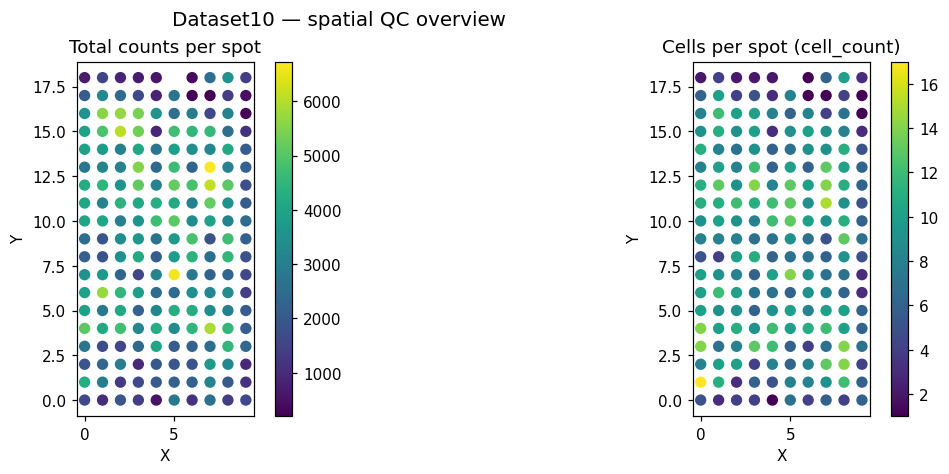

In [5]:
total_counts = np.asarray(adata.X).sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)
for ax, values, title in [
    (axes[0], total_counts,            "Total counts per spot"),
    (axes[1], adata.obs["cell_count"], "Cells per spot (cell_count)"),
]:
    sc = ax.scatter(adata.obs["X"], adata.obs["Y"], c=values,
                    cmap="viridis", s=55, edgecolors="none")
    ax.set_title(title)
    ax.set_xlabel("X"); ax.set_ylabel("Y")
    ax.set_aspect("equal")
    fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle("Dataset10 — spatial QC overview", fontsize=13)
plt.show()

## 2. Highly variable gene (HVG) selection

OT-NMF is fit on the most informative genes. `spotnmf.hvg` provides a batch-aware
over-dispersion test (`compute_overdispersed_genes`) that flags genes whose variance
exceeds a fitted mean–variance trend. The selected genes are stored in the boolean
column `adata.var["highly_variable"]`, which the model reads automatically.

On a real dataset you would call:

```python
adata, hvgs = spot.hvg.compute_overdispersed_genes(adata, alpha=0.05)
adata.var["highly_variable"] = adata.var.index.isin(hvgs)
```

Our *simulated* dataset already comes with all genes flagged as informative
(`uns["hvg"] = {'flavor': 'simulate'}`), so we simply use the existing flag.

In [6]:
n_hvg = int(adata.var["highly_variable"].sum())
print(f"{n_hvg} / {adata.n_vars} genes flagged as highly variable "
      f"(pre-selected for this simulated dataset).")

882 / 882 genes flagged as highly variable (pre-selected for this simulated dataset).


## 3. Run the OT-NMF deconvolution

The core solver is `spotnmf.models.run_spotnmf`. The most important knobs:

| Parameter | Role | Typical range |
|-----------|------|---------------|
| `components` (`k`) | number of latent programs to learn | data-dependent |
| `lr` | optimizer learning rate | `1e-3` |
| `h` | entropy regularization on **H** (gene spectra) — smaller ⇒ sparser | `0.001`–`1.0` |
| `w` | entropy regularization on **W** (spot usage) — smaller ⇒ sparser | `~1e-2` |
| `eps` | OT entropic regularization — larger ⇒ less weight on individual genes | `~5e-2` |
| `normalize_rows` | normalize each spot's profile before factorizing | `True` |

We pick **`k = 15`** here to match the 15 known cell types so we can validate
recovery in Section 6. On your own data, sweep a few values of `k` and inspect the
programs. Training prints a progress bar and stops early once the loss plateaus.

In [7]:
K = 15  # number of programs (chosen to match the 15 ground-truth cell types)

model_params = dict(
    lr=0.001,            # learning rate
    h=0.01,              # H (gene spectra) entropy regularization
    w=0.01,              # W (spot usage) entropy regularization
    eps=0.05,            # OT entropic regularization
    normalize_rows=True, # normalize per-spot profiles
)

results, losses = spot.models.run_spotnmf(adata, components=K, **model_params)

W = results["topics_per_spot"]   # spots  × programs   (usage)
H = results["genes_per_topic"]   # genes  × programs   (spectra)
print(f"\nW (topics_per_spot): {W.shape}")
print(f"H (genes_per_topic): {H.shape}")

Model Params: {'cost': 'cosine', 'optim_name': 'adam', 'tol_inner': 1e-12, 'tol_outer': 1e-05, 'max_iter': 100, 'max_iter_inner': 1000, 'device': 'cpu', 'lr': 0.001, 'h': 0.01, 'w': 0.01, 'eps': 0.05, 'normalize_rows': True}


  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:01<?, ?it/s, loss=?, loss_inner=0.01752995719564391, inner_steps=0, gpu_memory_allocated=0]

  0%|          | 0/200 [00:01<?, ?it/s, loss=?, loss_inner=0.010013568555194346, inner_steps=10, gpu_memory_allocated=0]

  0%|          | 0/200 [00:01<?, ?it/s, loss=?, loss_inner=0.002883865594607058, inner_steps=20, gpu_memory_allocated=0]

...

 26%|██▋       | 53/200 [05:50<13:40,  5.58s/it, loss=0.03173132719746, loss_inner=-0.04497395371284024, inner_steps=980, gpu_memory_allocated=0]

 26%|██▋       | 53/200 [05:50<13:40,  5.58s/it, loss=0.03173132719746, loss_inner=-0.044973936817753246, inner_steps=990, gpu_memory_allocated=0]

 27%|██▋       | 54/200 [05:50<14:53,  6.12s/it, loss=0.03173132719746, loss_inner=-0.044973936817753246, inner_steps=990, gpu_memory_allocated=0]

 27%|██▋       | 54/200 [05:50<15:46,  6.49s/it, loss=0.03173132719746, loss_inner=-0.044973936817753246, inner_steps=990, gpu_memory_allocated=0]


W (topics_per_spot): (189, 15)
H (genes_per_topic): (882, 15)


### Convergence

The optimizer alternates between updating **W** and **H**; the total dual loss is
recorded each step. A flattening curve indicates convergence.

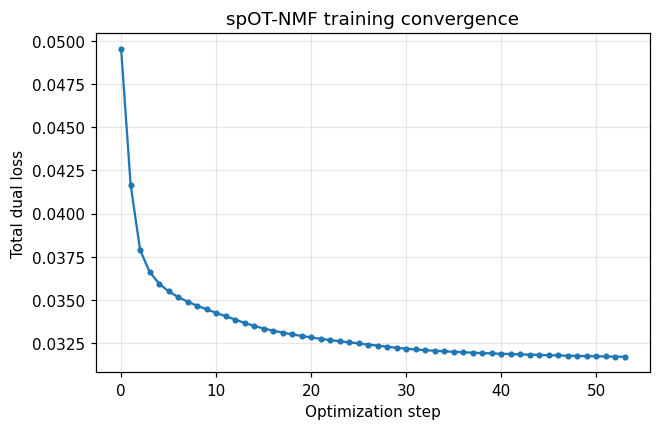

In [8]:
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot([float(l) for l in losses], marker="o", ms=3)
ax.set_xlabel("Optimization step")
ax.set_ylabel("Total dual loss")
ax.set_title("spOT-NMF training convergence")
ax.grid(alpha=0.3)
plt.show()

In [9]:
# W rows sum the program usage at each spot; the largest entry is the dominant program.
W.head()

,ot_1,ot_2,ot_3,ot_4,ot_5,ot_6,ot_7,ot_8,ot_9,ot_10,ot_11,ot_12,ot_13,ot_14,ot_15
0,0.038865,0.015177,0.067686,0.010643,0.206856,0.280099,0.022847,0.005017,0.046701,0.013995,0.042863,0.021718,0.014952,0.174312,0.038271
1,0.063142,0.057896,0.037693,0.034340,0.040964,0.198834,0.067184,0.035721,0.032998,0.015013,0.049100,0.067138,0.115704,0.141566,0.042709
2,0.012601,0.034437,0.042507,0.005730,0.050778,0.008142,0.100896,0.044200,0.020912,0.006005,0.052249,0.074747,0.431666,0.106272,0.008859
3,0.004516,0.002727,0.011952,0.060576,0.012195,0.004471,0.095084,0.049361,0.016973,0.034460,0.078850,0.023476,0.414560,0.151354,0.039449
4,0.105706,0.048089,0.051106,0.081320,0.170209,0.145303,0.049193,0.030637,0.043396,0.037631,0.055807,0.046184,0.072646,0.031251,0.031524


## 4. Spatial program maps

The columns of **W** are the deconvolved programs. Plotting each program's usage over
the tissue coordinates reveals its spatial domain. (The package also ships
`spotnmf.pl.plot_spatial_all_topics`, which writes publication-quality multi-page PDFs;
here we render inline for the tutorial.)

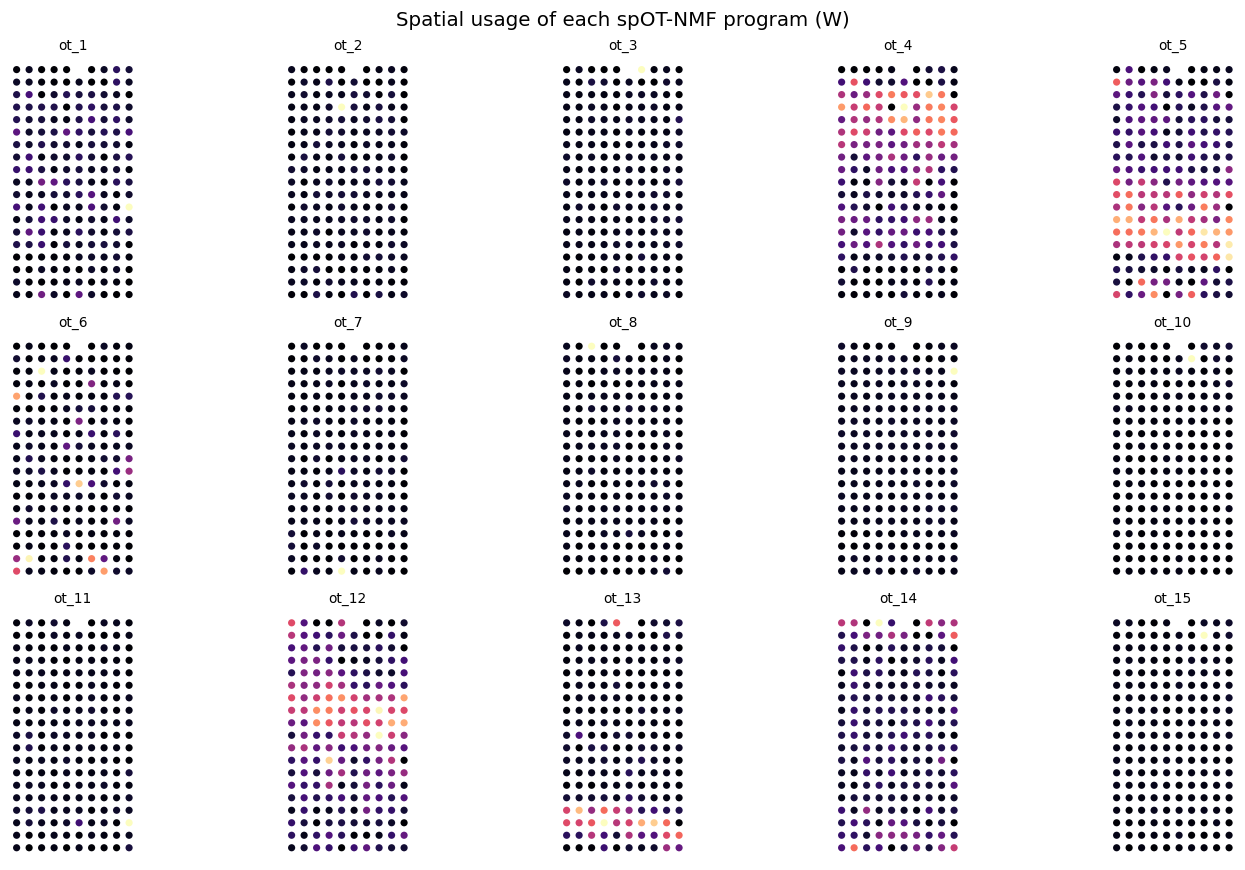

In [10]:
# Align the program usages with the spatial coordinates.
coords = adata.obs[["X", "Y"]].copy()
usage = coords.join(W)

programs = list(W.columns)
ncols = 5
nrows = int(np.ceil(len(programs) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.5, nrows * 2.6),
                         constrained_layout=True)
axes = np.atleast_1d(axes).ravel()

for ax, prog in zip(axes, programs):
    sc = ax.scatter(usage["X"], usage["Y"], c=usage[prog],
                    cmap="magma", s=22, edgecolors="none")
    ax.set_title(prog, fontsize=9)
    ax.set_aspect("equal"); ax.axis("off")
for ax in axes[len(programs):]:
    ax.axis("off")

fig.suptitle("Spatial usage of each spOT-NMF program (W)", fontsize=13)
plt.show()

## 5. Marker genes per program

To interpret a program biologically we rank genes by how strongly they drive it.
`spotnmf.gscore.calculate_marker_genes_topics_df` regresses (OLS) the z-scored
expression of every gene on the program usages, yielding a **gene × program**
coefficient matrix. The top-scoring genes are each program's markers.

In [11]:
gene_scores = spot.gscore.calculate_marker_genes_topics_df(adata, W)
print(f"gene_scores: {gene_scores.shape}  (genes × programs)")

# Top 8 marker genes for the first few programs.
top_markers = {
    prog: gene_scores[prog].sort_values(ascending=False).head(8).index.tolist()
    for prog in gene_scores.columns[:5]
}
pd.DataFrame(top_markers)

gene_scores: (882, 15)  (genes × programs)


,ot_1,ot_2,ot_3,ot_4,ot_5
0,Igfbp6,Rpp21,Mrap2,Calb1,Pcp4
1,Sstr4,Cxcl14,Reln,Rsph9,Arhgap25
2,Slc5a7,Gabra5,Mei1,Nell2,Tle4
3,Spry4,Tmem97,Gad1,Wfs1,Ogfrl1
4,Slc7a3,Pcdhga10,Fam131a,Pdzrn3,Col6a1
5,Acot13,Ptgs2,Cidea,Cacng3,Garnl3
6,Slc1a1,Tmem176b,Tmeff1,Lrrtm4,Rprm
7,Prlr,Pcdhb12,Slc5a5,Chodl,Nrp1


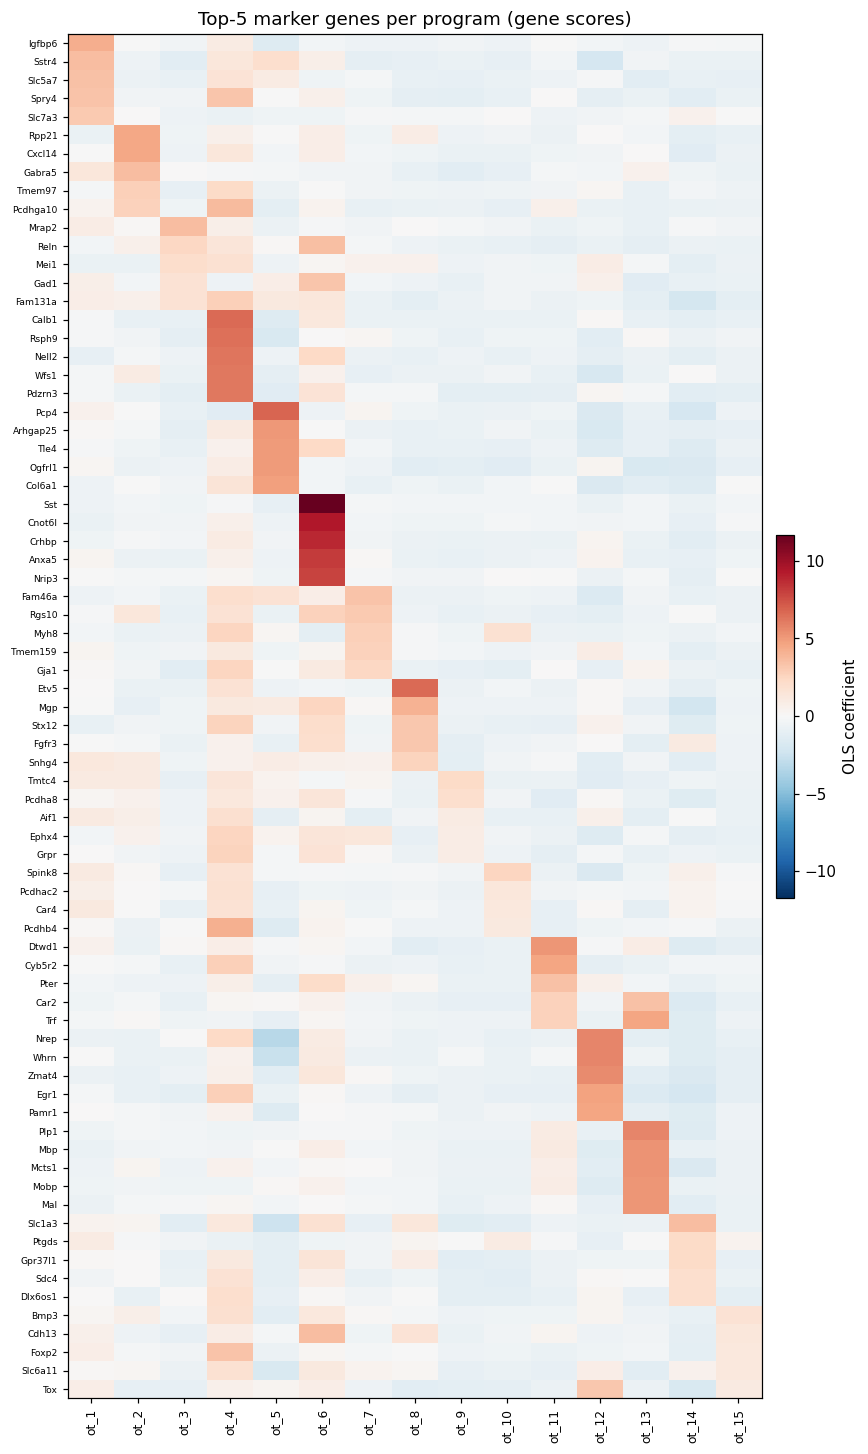

In [12]:
# Heatmap of the top markers (union of top-5 per program) across all programs.
top_n = 5
marker_genes = pd.unique(np.concatenate([
    gene_scores[p].sort_values(ascending=False).head(top_n).index.values
    for p in gene_scores.columns
]))
hm = gene_scores.loc[marker_genes]

fig, ax = plt.subplots(figsize=(8, max(6, len(marker_genes) * 0.18)))
im = ax.imshow(hm.values, aspect="auto", cmap="RdBu_r",
               vmin=-np.abs(hm.values).max(), vmax=np.abs(hm.values).max())
ax.set_xticks(range(hm.shape[1])); ax.set_xticklabels(hm.columns, rotation=90, fontsize=8)
ax.set_yticks(range(hm.shape[0])); ax.set_yticklabels(hm.index, fontsize=6)
ax.set_title(f"Top-{top_n} marker genes per program (gene scores)")
fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02, label="OLS coefficient")
plt.tight_layout()
plt.show()

## 6. Validate against ground-truth cell types

Because `Dataset10` is simulated, `adata.uns["ground_truth"]` holds the *true* number of
each cell type per spot. We normalize these to proportions and correlate them with the
recovered program usages — a good deconvolution should align each program with a
distinct cell type.

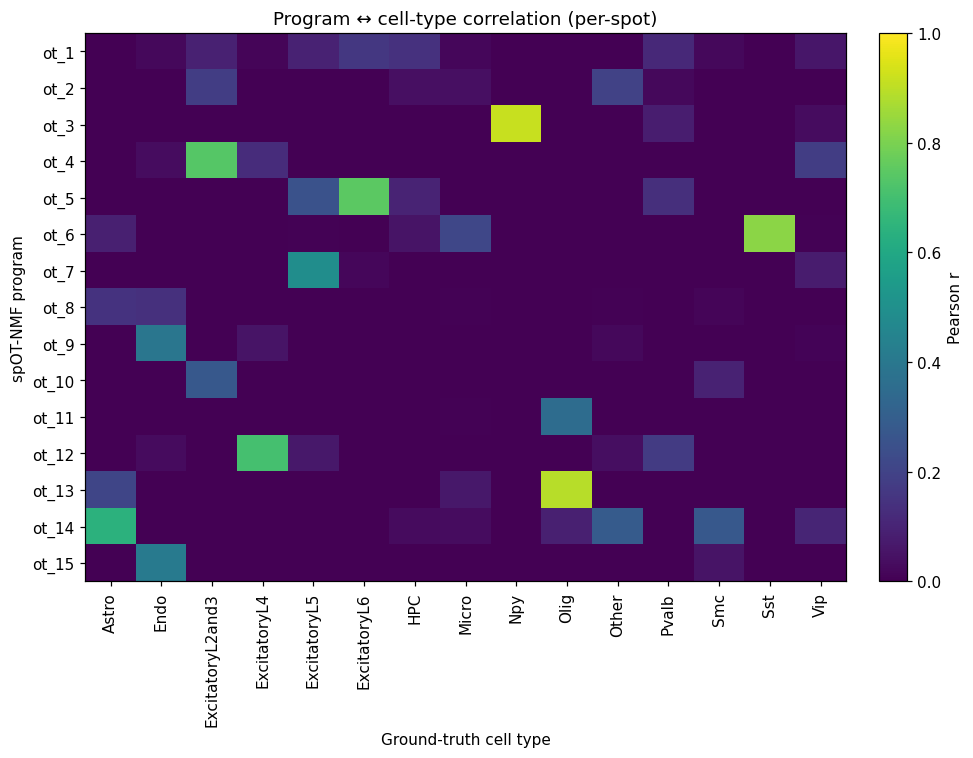

In [13]:
gt = adata.uns["ground_truth"].copy()
gt_prop = gt.div(gt.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)
gt_prop.index = W.index  # align spot order

# Program × cell-type Pearson correlation across spots.
corr = pd.DataFrame(index=W.columns, columns=gt_prop.columns, dtype=float)
for prog in W.columns:
    for ct in gt_prop.columns:
        corr.loc[prog, ct] = np.corrcoef(W[prog].values, gt_prop[ct].values)[0, 1]

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr.values.astype(float), cmap="viridis", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(corr.shape[1])); ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticks(range(corr.shape[0])); ax.set_yticklabels(corr.index)
ax.set_xlabel("Ground-truth cell type"); ax.set_ylabel("spOT-NMF program")
ax.set_title("Program ↔ cell-type correlation (per-spot)")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Pearson r")
plt.tight_layout()
plt.show()

In [14]:
# Greedy one-to-one assignment of programs to their best-matching cell type.
from spotnmf.eval import get_annotation_from_corr

assignment = get_annotation_from_corr(corr.astype(float))
assignment["pearson_r"] = [
    round(float(corr.loc[p, c]), 3)
    for p, c in zip(assignment["program"], assignment["celltype"])
]
print(f"Mean best-match correlation: {assignment['pearson_r'].mean():.3f}")
assignment.sort_values("pearson_r", ascending=False).reset_index(drop=True)

Mean best-match correlation: 0.451


,program,celltype,pearson_r
0,ot_3,Npy,0.914000
1,ot_13,Olig,0.894000
2,ot_6,Sst,0.826000
3,ot_5,ExcitatoryL6,0.747000
4,ot_4,ExcitatoryL2and3,0.737000
5,ot_12,ExcitatoryL4,0.704000
6,ot_14,Astro,0.642000
7,ot_7,ExcitatoryL5,0.491000
8,ot_15,Endo,0.408000
9,ot_2,Other,0.197000


### Side-by-side: recovered program vs. ground truth

For the three best-matched pairs, the predicted program usage closely tracks the true
cell-type proportion across the tissue.

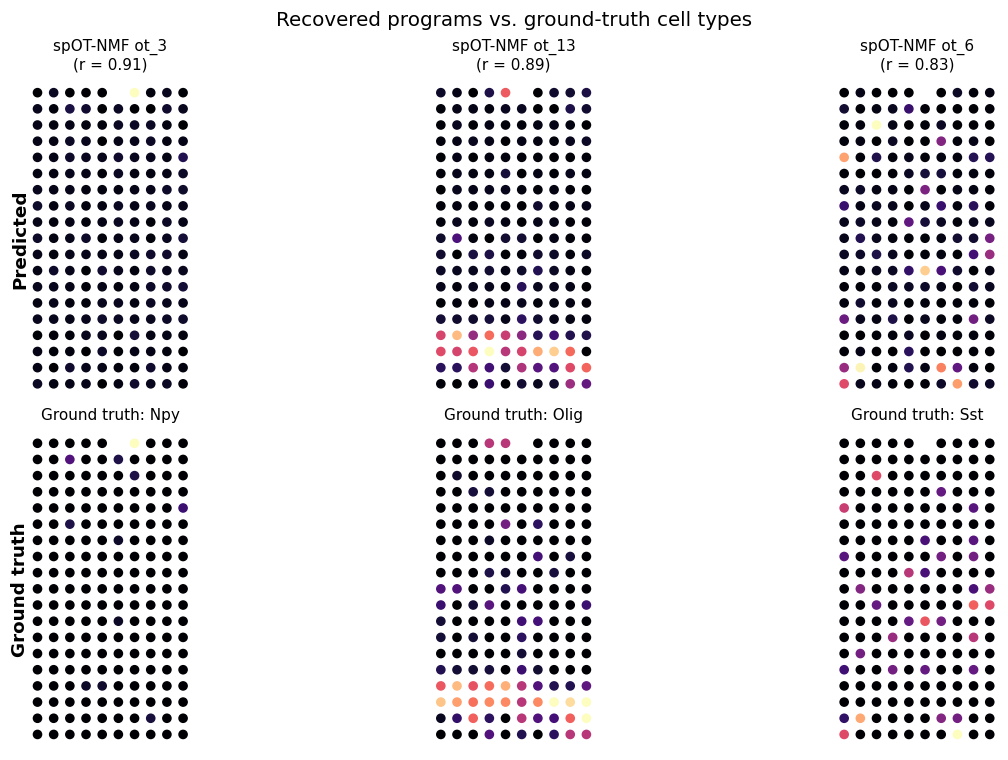

In [15]:
best = assignment.sort_values("pearson_r", ascending=False).head(3)

fig, axes = plt.subplots(2, 3, figsize=(11, 6.8), constrained_layout=True)
for j, (_, row) in enumerate(best.iterrows()):
    prog, ct, r = row["program"], row["celltype"], row["pearson_r"]
    # Top row: spOT-NMF prediction.
    a0 = axes[0, j]
    a0.scatter(adata.obs["X"], adata.obs["Y"], c=W[prog].values, cmap="magma", s=28)
    a0.set_title(f"spOT-NMF {prog}\n(r = {r:.2f})", fontsize=10)
    # Bottom row: ground-truth proportion.
    a1 = axes[1, j]
    a1.scatter(adata.obs["X"], adata.obs["Y"], c=gt_prop[ct].values, cmap="magma", s=28)
    a1.set_title(f"Ground truth: {ct}", fontsize=10)
    for a in (a0, a1):
        a.set_aspect("equal"); a.axis("off")

axes[0, 0].annotate("Predicted", xy=(-0.12, 0.5), xycoords="axes fraction",
                    rotation=90, va="center", fontsize=12, fontweight="bold")
axes[1, 0].annotate("Ground truth", xy=(-0.12, 0.5), xycoords="axes fraction",
                    rotation=90, va="center", fontsize=12, fontweight="bold")
fig.suptitle("Recovered programs vs. ground-truth cell types", fontsize=13)
plt.show()

## 7. Persisting results & the full production pipeline

In a real analysis you typically run the whole pipeline — **deconvolution → gene scores →
annotation → spatial plots → niche networks** — and save everything to disk. That is exactly
what `spotnmf.cli.run_experiment` does, and what the `spotnmf` command-line tool wraps.

```python
results = spot.cli.run_experiment(
    adata_spatial=adata,
    k=15,
    sample_name="Dataset10",
    results_dir="./results",
    genome="mm10",
    model_params=model_params,
    annotate=True,   # pathway enrichment + gene-set annotation (needs internet: g:Profiler)
    plot=True,       # write spatial program PDFs
    network=True,    # niche-network plots
)
```

Or equivalently from the shell:

```bash
spotnmf spotnmf \
  --sample_name Dataset10 \
  --adata_path data/test_data/dataset10_adata_spatial.h5ad \
  --data_mode h5ad \
  --results_dir ./results \
  --k 15 \
  --genome mm10
```

This writes `topics_per_spot_*.csv`, `genescores_per_topic_*.csv`,
`ranked_genescores_*.csv`, enrichment tables, and plots into `results/Dataset10/`.

> **Annotation requires internet access** (it queries the g:Profiler API). The cell below
> runs deconvolution + gene scoring to disk only; flip `RUN_ANNOTATION = True` to also
> enrich the programs.

In [16]:
RUN_ANNOTATION = False  # set True to also run g:Profiler enrichment (needs internet)

# Save the matrices we already computed, exactly as the CLI would lay them out.
results_dir = Path("results")
sample_dir = results_dir / "Dataset10"
sample_dir.mkdir(parents=True, exist_ok=True)

W.to_csv(sample_dir / "topics_per_spot_Dataset10.csv")
H.to_csv(sample_dir / "genes_per_topic_Dataset10.csv")
gene_scores.to_csv(sample_dir / "genescores_per_topic_Dataset10.csv")
spot.io.save_ranked_genes(gene_scores, sample_dir / "ranked_genescores_Dataset10.csv")
print("Saved core results to:", sample_dir.resolve())

if RUN_ANNOTATION:
    spot.cli.annotate_programs(results_dir=str(results_dir),
                               sample_name="Dataset10", genome="mm10")
    print("Annotation complete.")
else:
    print("Skipped annotation (set RUN_ANNOTATION=True to enable; requires internet).")

Saved core results to: Z:\postdoc\projects\spOT-NMF\docs\source\tutorials\results\Dataset10
Skipped annotation (set RUN_ANNOTATION=True to enable; requires internet).


## Summary & next steps

In this tutorial we:

1. Loaded a spatial AnnData object with `spotnmf.io.read_adata`,
2. Used pre-flagged highly variable genes (and saw how to compute them),
3. Ran the **OT-NMF deconvolution** to obtain program usages **W** and gene spectra **H**,
4. Mapped each program spatially and extracted its **marker genes**,
5. **Validated** the programs against ground-truth cell types (mean best-match r ≈ 0.5–0.9),
6. Saw how to persist results and run the **full CLI pipeline** with annotation and networks.

### Where to go next

- Sweep **`k`** and the regularizers (`h`, `w`, `eps`) on your own data.
- Use `spotnmf.pl.plot_spatial_all_topics` / `plot_spatial_all_topics_aggr` for
  publication-quality, multi-sample spatial figures.
- Run `spot.cli.annotate_programs(...)` (or `spotnmf annotate`) for pathway enrichment.
- Explore niche interactions with `spotnmf.niche_networks` / `spotnmf network`.

### Citation

> Abdelkareem, A.O., Gill, G.S., Manoharan, V.T., Verhey, T.B., & Morrissy, A.S.
> **spOT-NMF: Optimal Transport-Based Matrix Factorization for Accurate Deconvolution of
> Spatial Transcriptomics.** *bioRxiv* (2025).
> [doi:10.1101/2025.08.02.668292](https://doi.org/10.1101/2025.08.02.668292)

Questions or issues? → [github.com/MorrissyLab/spOT-NMF/issues](https://github.com/MorrissyLab/spOT-NMF/issues)